## Mecánica del vuelo - Tarea N°2: Velocidad y aerodinámica
### Datos simulados

#### Actividad 1

In [13]:
import numpy as np
with open('cessna172_actividad1.1.csv', 'r') as archivo:
    lineas = [line.rstrip(';') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [ft]

for i in lineas[1:-1]:
    np.array(v_indicated.append(float(i.split(';')[0])))
    np.array(v_true.append(float(i.split(';')[2])))
    np.array(altitude.append(float(i.split(';')[16])))


In [14]:
g0 = 9.80665     # m/s^2
R  = 287.05      # J/(kg K)

def z(H):
    """Altura geométrica H [km] -> altura geopotencial Z [km]"""
    return 6356.766*H/(6356.766 + H)

def T(T_i, T_grad, Z, Z_i):
    """T_grad en K/km ; Z, Z_i en km -> T en K"""
    return T_i + T_grad*(Z - Z_i)

def P(P_i, T_actual, T_i, T_grad):
    """T_grad en K/km -> P en las mismas unidades que P_i"""
    return P_i*(T_actual/T_i)**(-g0/(R*T_grad/1000))

def rho(P_actual, T_actual):
    return P_actual/(R*T_actual)

In [16]:
T0     = 15 + 273.15        # K, temperatura a nivel del mar
T_grad = -6.5                # K/km, gradiente en la troposfera
P0     = 29.92*3386.39       # Pa  (29.92 inHg -> Pa)
rho0   = P0/(R*T0)           # kg/m^3, debería dar ~1.225

Z, T_Z, P_Z, rho_Z = [], [], [], []

altitude_km= np.array(altitude)*0.3048/1000

for h in altitude_km:                 # altitude ya está en km
    Z_i   = z(h)
    T_i   = T(T0, T_grad, Z_i, 0)
    P_i   = P(P0, T_i, T0, T_grad)
    rho_i = rho(P_i, T_i)

    Z.append(Z_i)
    T_Z.append(T_i)
    P_Z.append(P_i)
    rho_Z.append(rho_i)


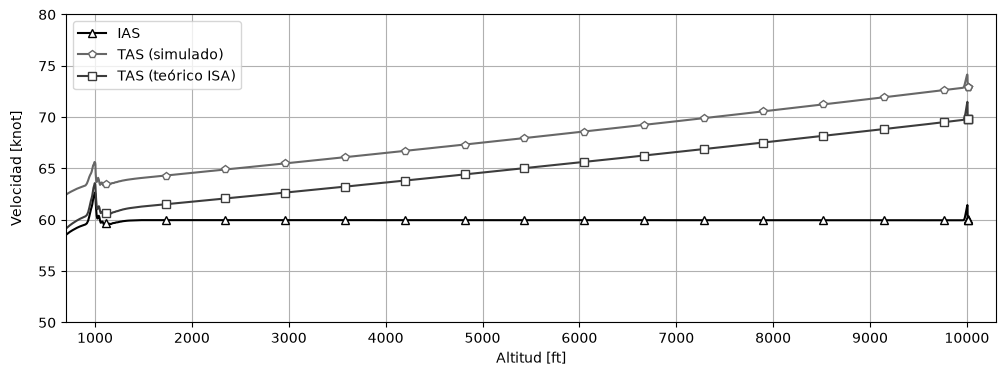

In [38]:
v_true_teo = [v_indicated[i]*np.sqrt(rho0/rho_Z[i]) for i in range(len(v_indicated))]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot( altitude,v_indicated, label='IAS', color='black', marker='^', markeredgecolor='black', markerfacecolor='white', markevery=95)
plt.plot(altitude,v_true, label='TAS (simulado)',color = '#676767', marker='p', markeredgecolor='#676767', markerfacecolor='white', markevery=95)
plt.plot(altitude,v_true_teo, label='TAS (teórico ISA)',color = "#3C3C3C", marker='s', markeredgecolor='#3C3C3C', markerfacecolor='white', markevery=95)
plt.xlabel('Altitud [ft]')
plt.ylabel('Velocidad [kn]')
plt.xticks(range(0, 10001, 1000))
plt.xlim(700, 10300)
plt.ylim(50,80)
plt.xlabel('Altitud [ft]')
plt.ylabel('Velocidad [knot]', labelpad=10)
plt.grid()
plt.legend()
plt.show()

#### Actividad 2
##### 2558 lb a 1000 ft

In [5]:
with open('cessna172-100kn-1000ft.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(',')[0]))
    v_true.append(float(i.split(',')[2]))
    lift.append((float(i.split(',')[20])+float(i.split(',')[22])+float(i.split(',')[24]))*4.45)
    drag.append((float(i.split(',')[26])+float(i.split(',')[28])+float(i.split(',')[30]))*4.45)
    altitude.append(float(i.split(',')[14]) * 0.3048 / 1000)
    alpha.append(float(i.split(',')[7]))

In [6]:
def cL(sust, altura):
    c_L = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(sust)):
        c_L.append(2 * sust[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_L

def cD(arr, altura):
    c_D = []
    if altura==1000: rho = 1.18955 # kg/m3
    else:            rho = 0.90464 # kg/m3
    for i in range(len(arr)):
        c_D.append(2 * arr[i] / (rho * 188*(0.3048**2) * (v_true[i]*0.514)**2))
    return c_D

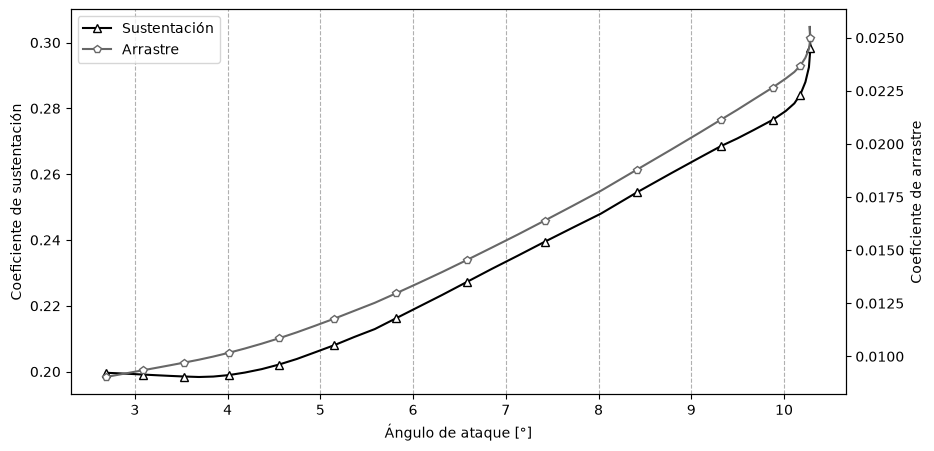

In [7]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

plotcl, = ax1.plot(alpha[28:-12], cL(lift[28:-12], 1000), color='black', marker='^', markeredgecolor='black', markerfacecolor='white', markevery=3)
ax1.set_xlabel('Ángulo de ataque [°]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2 = ax1.twinx()

plotcd, = ax2.plot(alpha[28:-12], cD(drag[28:-12], 1000), color = '#676767', marker='p', markeredgecolor='#676767', markerfacecolor='white', markevery=3)
ax2.set_ylabel('Coeficiente de arrastre')

ax1.grid(linestyle='--', axis='x')
plt.legend([plotcl, plotcd], ['Sustentación', 'Arrastre'], loc='upper left')

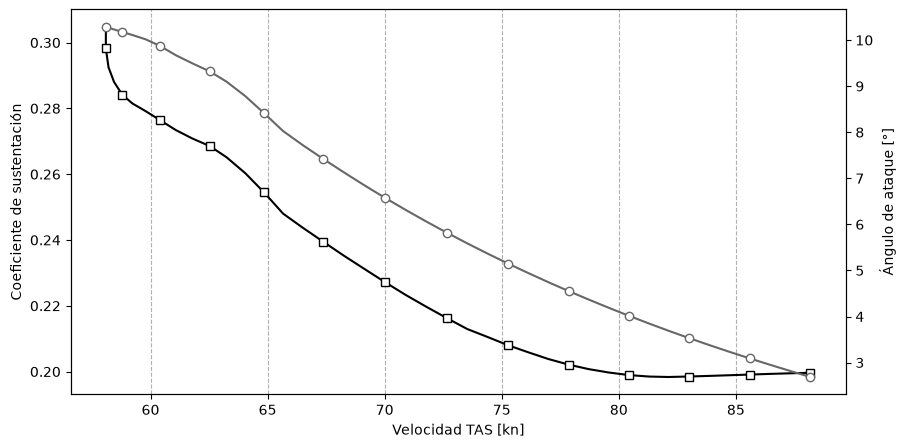

In [8]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1) = plt.subplots(1,1)

ax1.plot(v_true[28:-12], cL(lift[28:-12], 1000), color='black', marker='s', markeredgecolor='black', markerfacecolor='white', markevery=3)
ax1.set_xlabel('Velocidad TAS [kn]')
ax1.set_ylabel('Coeficiente de sustentación')

ax2 = ax1.twinx()

ax2.plot(v_true[28:-12], alpha[28:-12], color="#676767", marker='o', markeredgecolor='#676767', markerfacecolor='white', markevery=3)
ax2.set_xlabel('Velocidad TAS [kn]')
ax2.set_ylabel('Ángulo de ataque [°]')

ax1.grid(linestyle='--', axis='x')

##### 1730 lb a 1000 ft

In [9]:
with open('1000ft_1730lb_2.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]

# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(';')[7]))
    v_true.append(float(i.split(';')[9]))
    lift.append(float(i.split(';')[23])+float(i.split(';')[24])+float(i.split(';')[25])+float(i.split(';')[26])+float(i.split(';')[27])+float(i.split(';')[28])*4.45)
    drag.append(float(i.split(';')[29])+float(i.split(';')[30])+float(i.split(';')[31])+float(i.split(';')[32])+float(i.split(';')[33])+float(i.split(';')[34])*4.45)
    # altitude.append(float(i.split(';')[14]) * 0.3048 / 1000)
    alpha.append(float(i.split(';')[14]))

cl_1=cL(lift, 1000)
cd_1=cD(drag, 1000)
# print(cl)

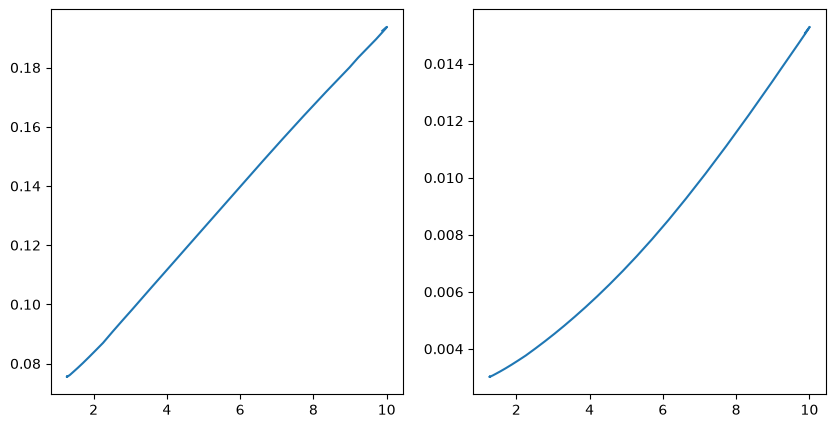

In [10]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha[100:143], cl_1[100:143])
ax2.plot(alpha[100:143], cd_1[100:143])

##### 2558 lb a 10000 ft

In [11]:
with open('10000ft_2558lb_2.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
altitude = []    # [km]
lift = []        # [N]
drag = []        # [N]
alpha = []       # [°]
CL=[]
CD=[]

# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated.append(float(i.split(';')[7]))
    v_true.append(float(i.split(';')[9]))
    lift.append((float(i.split(';')[23])+float(i.split(';')[24])+float(i.split(';')[25])+float(i.split(';')[26])+float(i.split(';')[27])+float(i.split(';')[28]))*4.45)
    # lift.append(float(i.split(';')[23])*4.45)
    drag.append((float(i.split(';')[29])+float(i.split(';')[30])+float(i.split(';')[31])+float(i.split(';')[32])+float(i.split(';')[33])+float(i.split(';')[34]))*4.45)
    # drag.append(float(i.split(';')[29])*4.45)
    # altitude.append(float(i.split(';')[14]) * 0.3048 / 1000)
    CL.append(float(i.split(';')[20]))
    CD.append(float(i.split(';')[21]))
    alpha.append(float(i.split(';')[14]))

cl_2=cL(lift, 10000)
cd_2=cD(drag, 10000)
# print(cl)

1.0715562099102118
0.5816231834844598


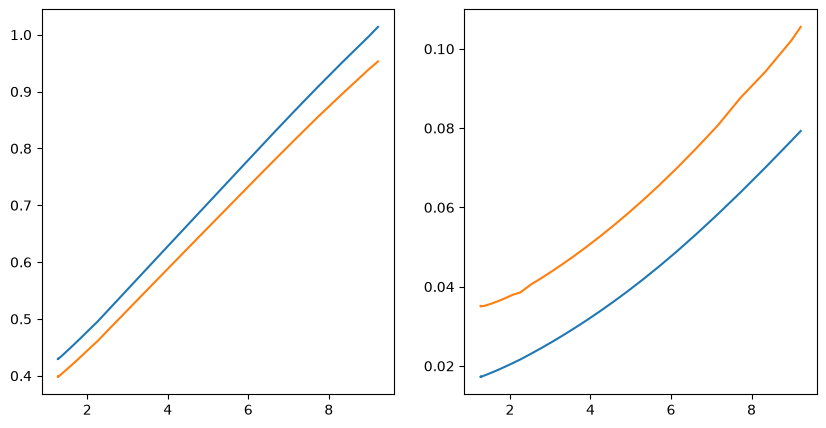

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(alpha[100:], cl_2[100:])
ax1.plot(alpha[100:], CL[100:])
ax2.plot(alpha[100:], cd_2[100:])
ax2.plot(alpha[100:], CD[100:])
print(cl_2[120]/CL[120])
print(cd_2[120]/CD[120])
